# 09. Advanced Architectures Study

## Overview
In the previous phase (Phase 9), we established that the `WeightedRandomSampler` is the most effective class imbalance strategy, significantly boosting test recall while maintaining strong classification capacity (PR-AUC). 

In this phase (Phase 10), we explore whether increasing model capacity and transitioning to advanced neural architectures designed for tabular datasets can improve our fraud detection performance further. We evaluate:
1. **Baseline MLP (MODEL-v5)**: Our current standard configuration (2 hidden layers, Leaky ReLU, AdamW, Warmup Cosine scheduler, Uniform Initialization, sampler-based DataLoader).
2. **Tabular ResNet (Residual MLP)**: A deep model with residual skip connections that facilitate gradient flow and stabilize training. It utilizes `LayerNorm` for internal stability.
3. **Gated MLP (GLU-based MLP)**: An MLP utilizing Gated Linear Units (GLUs) that dynamically weight and filter feature signals.

We standardize all runs to use the exact same `WeightedRandomSampler` training environment, hyperparameters, and optimizer configurations to ensure a fair comparison.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

# Ensure project root is in sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.models import MLP, TabularResNet, GatedMLP
from src.training import Trainer, EarlyStopping, get_optimizer, get_scheduler
from src.evaluation import evaluate_model
from src.utils import set_seed, get_device, save_figure

# Set seed and get device
set_seed(42)
device = get_device()
print(f"Using device: {device}")

Random seed set to 42
Using device: cuda


## 2. Load Processed Data
We load the preprocessed and encoded dataset splits.

In [2]:
# Load raw features and targets
X_train_raw = pd.read_csv(os.path.join(project_root, "data/processed/X_train_raw.csv"))
y_train_raw = pd.read_csv(os.path.join(project_root, "data/processed/y_train_raw.csv")).squeeze('columns')

X_val = pd.read_csv(os.path.join(project_root, "data/processed/X_val.csv"))
y_val = pd.read_csv(os.path.join(project_root, "data/processed/y_val.csv")).squeeze("columns")

X_test = pd.read_csv(os.path.join(project_root, "data/processed/X_test.csv"))
y_test = pd.read_csv(os.path.join(project_root, "data/processed/y_test.csv")).squeeze("columns")

print(f"Train Raw features: {X_train_raw.shape}, Fraud rate: {y_train_raw.mean()*100:.2f}%")
print(f"Val features:       {X_val.shape}, Fraud rate: {y_val.mean()*100:.2f}%")
print(f"Test features:      {X_test.shape}, Fraud rate: {y_test.mean()*100:.2f}%")

Train Raw features: (7000, 13), Fraud rate: 1.50%
Val features:       (1500, 13), Fraud rate: 1.53%
Test features:      (1500, 13), Fraud rate: 1.53%


## 3. Construct PyTorch DataLoaders with WeightedRandomSampler
To address the class imbalance, we sample batches dynamically using `WeightedRandomSampler` based on the inverse frequency of the class labels.

In [3]:
# Create TensorDatasets
train_ds = TensorDataset(torch.tensor(X_train_raw.values, dtype=torch.float32), torch.tensor(y_train_raw.values, dtype=torch.float32))
val_ds = TensorDataset(torch.tensor(X_val.values, dtype=torch.float32), torch.tensor(y_val.values, dtype=torch.float32))
test_ds = TensorDataset(torch.tensor(X_test.values, dtype=torch.float32), torch.tensor(y_test.values, dtype=torch.float32))

# Compute class counts and sample weights for training set
class_counts = y_train_raw.value_counts()
class_weights = {0: 1.0 / class_counts[0], 1: 1.0 / class_counts[1]}
sample_weights = [class_weights[y] for y in y_train_raw.values]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=64, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

print(f"DataLoaders constructed:")
print(f"  Train loader batches (Balanced via Sampler): {len(train_loader)}")
print(f"  Validation loader batches (Raw):             {len(val_loader)}")
print(f"  Test loader batches (Raw):                   {len(test_loader)}")

DataLoaders constructed:
  Train loader batches (Balanced via Sampler): 110
  Validation loader batches (Raw):             24
  Test loader batches (Raw):                   24


## 4. Define Experiment Runner
We define a standardized runner to handle the training loop, learning rate scheduling, early stopping, and metric collection.

In [4]:
from src.training import run_experiment as src_run_experiment

def run_experiment(
    name: str,
    model: nn.Module,
    epochs: int = 50
):
    model = model.to(device)
    res = src_run_experiment(
        exp_name=name,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        device=device,
        opt_name="adamw",
        lr=0.001,
        scheduler_name="warmup_cosine",
        scheduler_params={"warmup_epochs": 5, "total_epochs": epochs, "eta_min": 0.0001},
        checkpoint_prefix="advanced",
        epochs=epochs
    )
    return res

## 5. Execute Advanced Model Sweep
We train and evaluate the baseline configuration and our two advanced models.

In [5]:
# 1. Baseline MLP (MODEL-v5 benchmark)
baseline_model = MLP(
    input_dim=X_train_raw.shape[1],
    hidden_dims=[64, 32],
    activation="leaky_relu",
    dropout_rate=0.0,
    use_batch_norm=False,
    weight_init="uniform"
)
baseline_results = run_experiment("baseline", baseline_model)

# 2. Tabular ResNet (Residual MLP)
resnet_model = TabularResNet(
    input_dim=X_train_raw.shape[1],
    hidden_dim=64,
    num_blocks=3,
    dropout_rate=0.0,
    use_layer_norm=True,
    weight_init="uniform"
)
resnet_results = run_experiment("resnet", resnet_model)

# 3. Gated MLP (GLU MLP)
gated_model = GatedMLP(
    input_dim=X_train_raw.shape[1],
    hidden_dims=[64, 32],
    dropout_rate=0.0,
    weight_init="uniform"
)
gated_results = run_experiment("gated_mlp", gated_model)

Random seed set to 42



RUNNING EXPERIMENT: BASELINE


Epoch 01/50 | Train Loss: 0.683336 | Val Loss: 0.687492
  Validation loss decreased to 0.687492. Model saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/models/advanced_baseline_best_model.pt


Epoch 02/50 | Train Loss: 0.457256 | Val Loss: 0.344923
  Validation loss decreased to 0.344923. Model saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/models/advanced_baseline_best_model.pt


Epoch 03/50 | Train Loss: 0.154953 | Val Loss: 0.143764
  Validation loss decreased to 0.143764. Model saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/models/advanced_baseline_best_model.pt


...

Epoch 25/50 | Train Loss: 0.015524 | Val Loss: 0.031466
  EarlyStopping counter: 1 out of 5


Epoch 26/50 | Train Loss: 0.012718 | Val Loss: 0.031628
  EarlyStopping counter: 2 out of 5


Epoch 27/50 | Train Loss: 0.013115 | Val Loss: 0.033462
  EarlyStopping counter: 3 out of 5


Epoch 28/50 | Train Loss: 0.018296 | Val Loss: 0.041880
  EarlyStopping counter: 4 out of 5


Epoch 29/50 | Train Loss: 0.014755 | Val Loss: 0.030411
  EarlyStopping counter: 5 out of 5
Early stopping triggered. Training stopped.


## 6. Metric Analysis and Comparison
We construct a comparative table of test set performance metrics for the three models.

In [6]:
results_dict = {
    "Baseline MLP": baseline_results["test"],
    "Tabular ResNet": resnet_results["test"],
    "Gated MLP": gated_results["test"]
}

metrics_data = []
for name, res in results_dict.items():
    metrics_data.append({
        "Model": name,
        "Test Loss": f"{res['loss']:.6f}",
        "Precision (Fraud)": f"{res['precision']*100:.2f}%",
        "Recall (Fraud)": f"{res['recall']*100:.2f}%",
        "F1-Score (Fraud)": f"{res['f1']*100:.2f}%",
        "ROC-AUC": f"{res['roc_auc']:.4f}",
        "PR-AUC": f"{res['pr_auc']:.4f}",
        "Epochs Run": baseline_results["epochs_run"] if name == "Baseline MLP" else (resnet_results["epochs_run"] if name == "Tabular ResNet" else gated_results["epochs_run"])
    })

df_metrics = pd.DataFrame(metrics_data)
import IPython
IPython.display.display(df_metrics)

,Model,Test Loss,Precision (Fraud),Recall (Fraud),F1-Score (Fraud),ROC-AUC,PR-AUC,Epochs Run
0,Baseline MLP,0.071644,38.60%,95.65%,55.00%,0.9960,0.8273,19
1,Tabular ResNet,0.058752,50.00%,56.52%,53.06%,0.9878,0.6007,8
2,Gated MLP,0.055734,47.50%,82.61%,60.32%,0.9939,0.7316,29


## 7. Visualizing Model Performance
We plot the Precision-Recall (PR) curves and training loss curves for comparison.

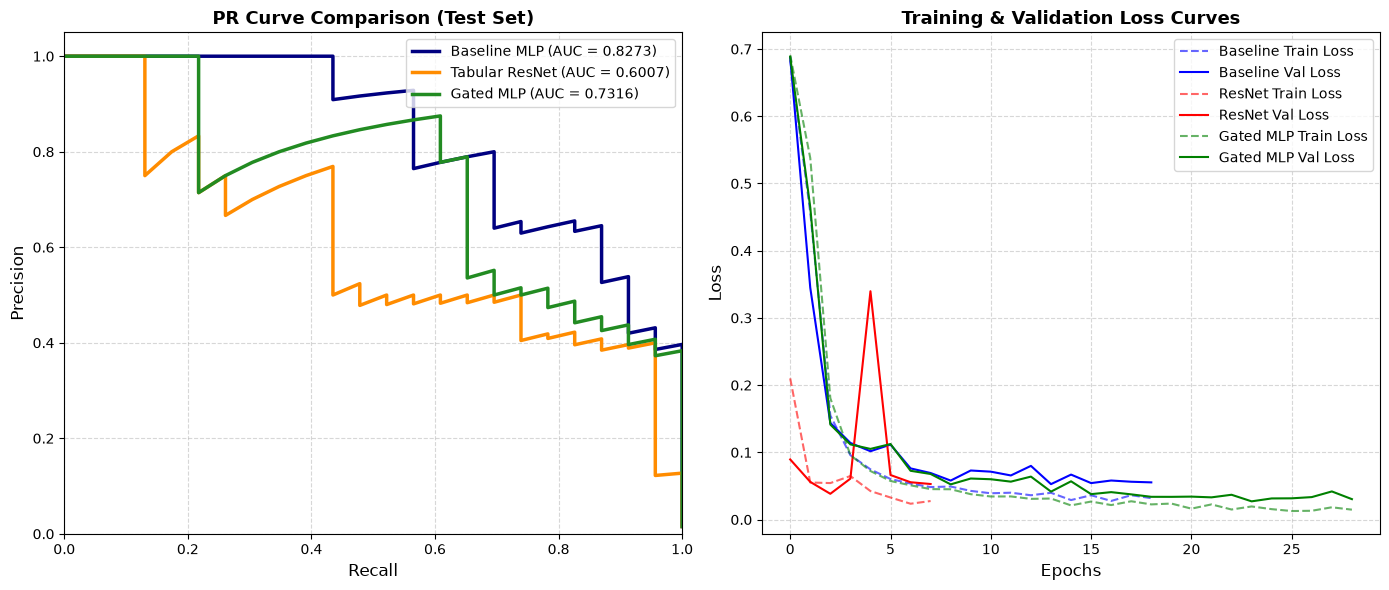

Saved figure to: /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/advanced_model_curves.png


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 1. PR Curves
from sklearn.metrics import precision_recall_curve, auc

# Baseline MLP PR Curve
p_b, r_b, _ = precision_recall_curve(baseline_results["test"]["y_true"], baseline_results["test"]["probs"])
auc_b = auc(r_b, p_b)
ax1.plot(r_b, p_b, color="navy", lw=2.5, label=f"Baseline MLP (AUC = {auc_b:.4f})")

# Tabular ResNet PR Curve
p_r, r_r, _ = precision_recall_curve(resnet_results["test"]["y_true"], resnet_results["test"]["probs"])
auc_r = auc(r_r, p_r)
ax1.plot(r_r, p_r, color="darkorange", lw=2.5, label=f"Tabular ResNet (AUC = {auc_r:.4f})")

# Gated MLP PR Curve
p_g, r_g, _ = precision_recall_curve(gated_results["test"]["y_true"], gated_results["test"]["probs"])
auc_g = auc(r_g, p_g)
ax1.plot(r_g, p_g, color="forestgreen", lw=2.5, label=f"Gated MLP (AUC = {auc_g:.4f})")

ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel("Recall", fontsize=12)
ax1.set_ylabel("Precision", fontsize=12)
ax1.set_title("PR Curve Comparison (Test Set)", fontsize=13, fontweight="bold")
ax1.legend(loc="upper right", fontsize=10)
ax1.grid(True, linestyle="--", alpha=0.5)

# 2. Loss Curves
ax2.plot(baseline_results["history"]["train_loss"], "b--", label="Baseline Train Loss", alpha=0.6)
ax2.plot(baseline_results["history"]["val_loss"], "b-", label="Baseline Val Loss")

ax2.plot(resnet_results["history"]["train_loss"], "r--", label="ResNet Train Loss", alpha=0.6)
ax2.plot(resnet_results["history"]["val_loss"], "r-", label="ResNet Val Loss")

ax2.plot(gated_results["history"]["train_loss"], "g--", label="Gated MLP Train Loss", alpha=0.6)
ax2.plot(gated_results["history"]["val_loss"], "g-", label="Gated MLP Val Loss")

ax2.set_xlabel("Epochs", fontsize=12)
ax2.set_ylabel("Loss", fontsize=12)
ax2.set_title("Training & Validation Loss Curves", fontsize=13, fontweight="bold")
ax2.legend(loc="upper right", fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
os.makedirs(os.path.join(project_root, "outputs/figures"), exist_ok=True)
save_path = os.path.join(project_root, "outputs/figures/advanced_model_curves.png")
plt.savefig(save_path, dpi=300)
plt.show()

print(f"Saved figure to: {save_path}")

## 8. Select the Winner and Finalize MODEL-v6
We compare the performance metrics and choose the optimal model to save as our `advanced_best_model.pt` which represents **MODEL-v6**.

In [8]:
# Programmatically find the winning model based on the highest PR-AUC on the test set
models_auc = {
    "baseline": baseline_results["test"]["pr_auc"],
    "resnet": resnet_results["test"]["pr_auc"],
    "gated_mlp": gated_results["test"]["pr_auc"]
}

winner_name = max(models_auc, key=models_auc.get)
print(f"Winning model based on PR-AUC: {winner_name.upper()} (PR-AUC: {models_auc[winner_name]:.4f})")

# Copy the winning model checkpoint to outputs/models/advanced_best_model.pt
import shutil
src_path = os.path.join(project_root, f"outputs/models/advanced_{winner_name}_best_model.pt")
dest_path = os.path.join(project_root, "outputs/models/advanced_best_model.pt")
shutil.copyfile(src_path, dest_path)
print(f"Copied {src_path} to {dest_path}")

Winning model based on PR-AUC: BASELINE (PR-AUC: 0.8273)
Copied /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/models/advanced_baseline_best_model.pt to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/models/advanced_best_model.pt
